# Laboratorio 4 (Parte 2) — Inciso 1: Preparación de los datos para Machine Learning

A partir de los rasters de la Parte I (22 combinaciones lago-fecha, 18 bandas por raster) se construye una tabla de observaciones a nivel de píxel de agua válido, con coordenadas, fecha, lago, bandas espectrales, NDVI, NDWI e índice de cianobacteria (`clorofila`), lista para los modelos de clasificación de los incisos siguientes.

El evalscript de descarga (`src/evalscripts.py`) se amplió respecto a la Parte I: adicional a las 10 bandas originales, ahora también entrega las reflectancias B05, B07, B08, B8A, B11 y B12, y las bandas de nube CLM y CLP de Sentinel Hub. Los 22 rasters se re-descargaron con este evalscript ampliado antes de ejecutar este notebook.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer

from src.config import FECHAS_OFICIALES, LAGOS, RUTA_DATA_PROCESSED, RUTA_FIGURAS
from src.dataset import construir_dataset, mapa_motivo_descarte, mascara_agua_estable, muestra_trabajo

colores = {"atitlan": "teal", "amatitlan": "darkorange"}

## 1.1 a 1.3 Construcción y limpieza del dataset

Por cada combinación lago-fecha (`src.dataset.tabla_fecha`) se calcula el centro de cada píxel en WGS84 a partir del `transform` del raster, se reproyecta a UTM 15N (EPSG:32615, unidades en metros) y se aplican, en orden, los siguientes filtros de validez:

1. **Máscara de datos válidos** (`mascara == 1`): descarta NoData y área fuera de la huella descargada.
2. **Agua** (`agua == 1`): descarta tierra firme alrededor del lago, usando la máscara espectral ya calculada en la Parte I.
3. **Nube o sombra de nube**: descarta píxeles con `CLM == 1` (nube confirmada por s2cloudless) o `CLP >= 0.35` (probabilidad de nube). `CLM` usa el valor 255 como "sin dato" del modelo, no como nube; tratarlo como nube descartaría de forma injustificada hasta el 92% del agua válida en algunas fechas, por lo que solo se excluye `CLM == 1` y se deja a `CLP` —que sí trae un valor continuo incluso donde `CLM` es "sin dato"— como criterio principal.
4. **Reflectancia válida**: las 9 bandas ópticas deben ser finitas y estar en `(0, 1.6]`, lo que descarta píxeles saturados, negativos o corruptos.
5. **Denominador del NDCI estable**: `|B04 + B05| > 1e-4`, para descartar el pequeño número de píxeles de borde donde el NDCI (y por lo tanto `clorofila`) es matemáticamente inestable, ya documentado en la Parte I.
6. **Agua estable**: el píxel debe clasificarse como agua en al menos 9 de las 11 fechas oficiales de su lago (`src.dataset.mascara_agua_estable`), mismo criterio usado en el inciso 8 de la Parte I para descartar píxeles de orilla observados como agua en muy pocas fechas.

In [2]:
dataset, resumen_filtros = construir_dataset()
print(f"Observaciones válidas totales: {len(dataset):,}")
dataset.head()

Observaciones válidas totales: 3,753,732


,lago,fecha,fila,columna,lon,lat,rojo,verde,azul,b05,...,b11,b12,ndci,clorofila,fai,ndvi,ndwi,clp,x_utm,y_utm
0,atitlan,2025-01-18,18,839,-91.169583,14.747677,0.0242,0.0492,0.0705,0.0200,...,0.0138,0.0070,-0.095023,-0.036656,-0.001509,0.026157,0.317269,10.0,697041.7500,1631219.625
1,atitlan,2025-01-18,18,840,-91.169396,14.747677,0.0256,0.0474,0.0706,0.0201,...,0.0078,0.0041,-0.120350,-2.211941,0.002969,-0.057851,0.350427,10.0,697061.8750,1631219.875
2,atitlan,2025-01-18,18,841,-91.169209,14.747677,0.0239,0.0474,0.0712,0.0206,...,0.0076,0.0039,-0.074157,1.354682,0.000383,-0.017021,0.344681,10.0,697081.9375,1631220.000
3,atitlan,2025-01-18,18,842,-91.169023,14.747677,0.0237,0.0476,0.0717,0.0232,...,0.0098,0.0066,-0.010661,3.847387,0.003249,-0.079727,0.404130,10.0,697102.0625,1631220.125
4,atitlan,2025-01-18,18,843,-91.168836,14.747677,0.0247,0.0479,0.0719,0.0230,...,0.0107,0.0072,-0.035639,3.132338,0.002216,-0.105145,0.410898,3.0,697122.1875,1631220.375


### Efecto de cada filtro sobre el número de observaciones

In [3]:
columnas_filtro = [
    "n_total", "n_mascara_valida", "n_agua", "n_sin_nubes",
    "n_reflectancia_valida", "n_ndci_valido", "n_agua_estable",
]
efecto_filtros = resumen_filtros.groupby("lago", observed=True)[columnas_filtro].sum()
efecto_filtros_pct = efecto_filtros.div(efecto_filtros["n_total"], axis=0) * 100
efecto_filtros.to_csv(RUTA_DATA_PROCESSED / "p2_filtros_limpieza.csv")
efecto_filtros

,n_total,n_mascara_valida,n_agua,n_sin_nubes,n_reflectancia_valida,n_ndci_valido,n_agua_estable
lago,,,,,,,
amatitlan,3375460,3375460,402526,401529,401525,401525,396165
atitlan,13138125,13138125,3377514,3375444,3373000,3373000,3357567


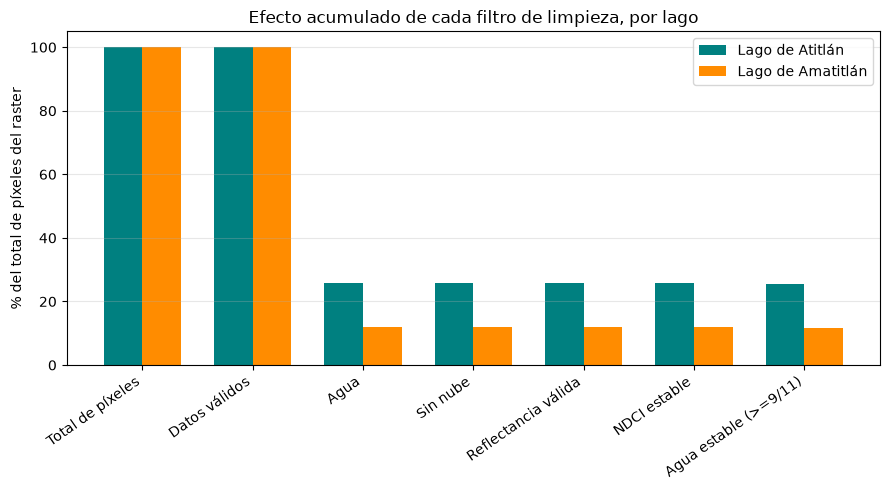

In [4]:
etapas_nombres = {
    "n_total": "Total de píxeles",
    "n_mascara_valida": "Datos válidos",
    "n_agua": "Agua",
    "n_sin_nubes": "Sin nube",
    "n_reflectancia_valida": "Reflectancia válida",
    "n_ndci_valido": "NDCI estable",
    "n_agua_estable": "Agua estable (>=9/11)",
}

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(etapas_nombres))
ancho = 0.35
for i, lago in enumerate(LAGOS):
    valores = efecto_filtros_pct.loc[lago, list(etapas_nombres)]
    ax.bar(x + i * ancho, valores, width=ancho, label=LAGOS[lago]["nombre"], color=colores[lago])
ax.set_xticks(x + ancho / 2)
ax.set_xticklabels(list(etapas_nombres.values()), rotation=35, ha="right")
ax.set_ylabel("% del total de píxeles del raster")
ax.set_title("Efecto acumulado de cada filtro de limpieza, por lago")
ax.legend()
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "p2_efecto_filtros.png", dpi=150)
plt.show()

La caída más grande ocurre siempre en el filtro de agua, ya que la mayoría de cada raster es tierra firme alrededor del lago: en Atitlán, cuyo bbox es más ancho respecto al cuerpo del lago, queda alrededor de 26% de agua; en Amatitlán, con un bbox más ajustado, queda cerca de 12%. Los filtros siguientes (nube, reflectancia, NDCI, agua estable) recortan cada uno una fracción pequeña adicional, salvo en fechas puntuales con nubosidad real (2026-04-28 en ambos lagos).

## 1.4 Número de observaciones, variables y valores faltantes

In [5]:
resumen_general = pd.DataFrame({
    "lago": list(LAGOS),
    "nombre": [LAGOS[l]["nombre"] for l in LAGOS],
    "n_observaciones": [int((dataset["lago"] == l).sum()) for l in LAGOS],
    "n_fechas": [dataset.loc[dataset["lago"] == l, "fecha"].nunique() for l in LAGOS],
})
resumen_general

,lago,nombre,n_observaciones,n_fechas
0,atitlan,Lago de Atitlán,3357567,11
1,amatitlan,Lago de Amatitlán,396165,11


In [6]:
observaciones_por_fecha = (
    dataset.groupby(["lago", "fecha"], observed=True)
    .size()
    .reset_index(name="n_observaciones")
    .sort_values(["lago", "fecha"])
)
observaciones_por_fecha.to_csv(RUTA_DATA_PROCESSED / "p2_resumen_dataset.csv", index=False)
observaciones_por_fecha

,lago,fecha,n_observaciones
0,amatitlan,2025-01-28,36276
1,amatitlan,2025-04-15,36219
2,amatitlan,2025-04-28,36141
3,amatitlan,2025-11-24,36172
4,amatitlan,2026-01-08,36281
5,amatitlan,2026-02-02,36010
6,amatitlan,2026-02-07,36383
7,amatitlan,2026-03-29,36388
8,amatitlan,2026-04-13,36390
9,amatitlan,2026-04-28,33578


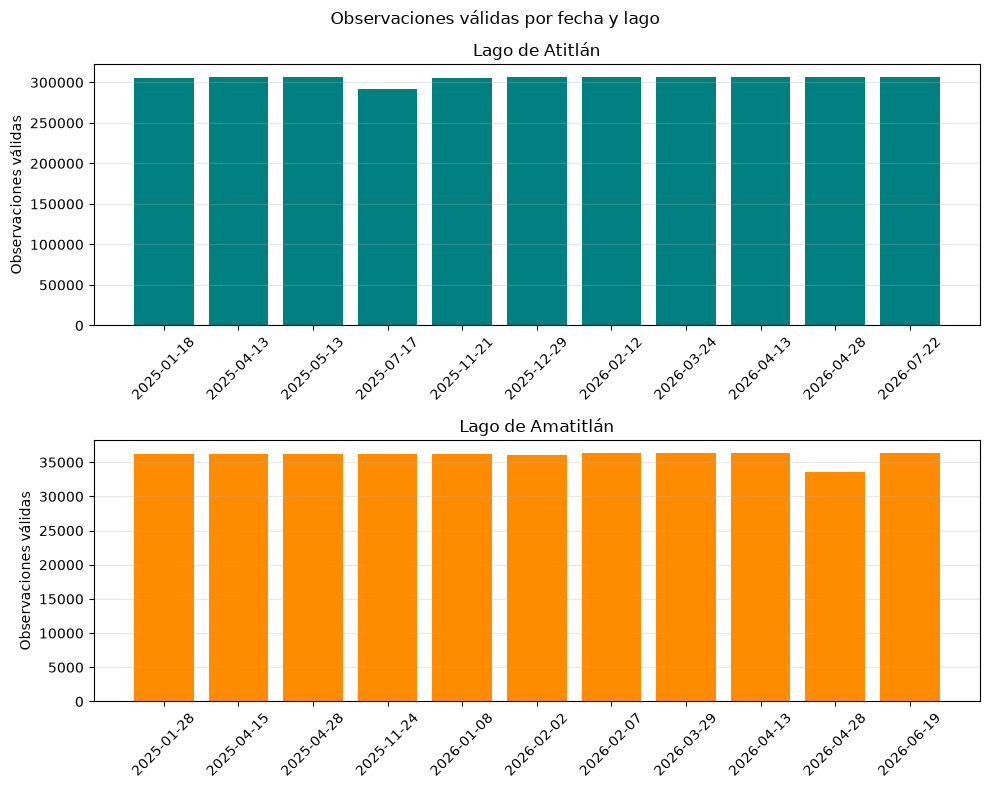

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
for ax, lago in zip(axes, LAGOS):
    sub = observaciones_por_fecha[observaciones_por_fecha["lago"] == lago]
    ax.bar(sub["fecha"].dt.strftime("%Y-%m-%d"), sub["n_observaciones"], color=colores[lago])
    ax.set_title(LAGOS[lago]["nombre"])
    ax.set_ylabel("Observaciones válidas")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3, axis="y")
fig.suptitle("Observaciones válidas por fecha y lago")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "p2_observaciones_por_lago_fecha.png", dpi=150)
plt.show()

### Variables disponibles, tipo de dato y porcentaje de valores faltantes

In [8]:
tabla_variables = pd.DataFrame({
    "variable": dataset.columns,
    "tipo": [str(dataset[c].dtype) for c in dataset.columns],
    "pct_faltantes": [float(dataset[c].isna().mean() * 100) for c in dataset.columns],
    "valor_min": [dataset[c].min() if pd.api.types.is_numeric_dtype(dataset[c]) else None for c in dataset.columns],
    "valor_max": [dataset[c].max() if pd.api.types.is_numeric_dtype(dataset[c]) else None for c in dataset.columns],
})
tabla_variables.to_csv(RUTA_DATA_PROCESSED / "p2_tabla_variables.csv", index=False)
tabla_variables

,variable,tipo,pct_faltantes,valor_min,valor_max
0,lago,category,0.0,NaN,NaN
1,fecha,datetime64[us],0.0,NaN,NaN
2,fila,int32,0.0,1.500000e+01,7.750000e+02
3,columna,int32,0.0,1.440000e+02,1.128000e+03
4,lon,float64,0.0,-9.128678e+01,-9.052927e+01
5,lat,float64,0.0,1.441244e+01,1.474768e+01
6,rojo,float32,0.0,1.830000e-02,2.297000e-01
7,verde,float32,0.0,3.810000e-02,2.618000e-01
8,azul,float32,0.0,6.080000e-02,2.816000e-01
9,b05,float32,0.0,1.200000e-02,2.469000e-01


Ninguna variable presenta valores faltantes: los filtros de limpieza del inciso 1.1-1.3 ya descartaron todo píxel con NoData, tierra, nube, reflectancia inválida o denominador inestable antes de construir la tabla, por lo que cada fila retenida tiene sus 15 bandas/índices completos.

## 1.5 Análisis exploratorio de las variables

In [9]:
variables_modelado = ["rojo", "verde", "azul", "b05", "b07", "b08", "b8a", "b11", "b12",
                       "ndci", "clorofila", "fai", "ndvi", "ndwi", "clp"]
dataset.groupby("lago", observed=True)[variables_modelado].describe().T.round(4)

lago          amatitlan       atitlan
rojo count  396165.0000  3.357567e+06
     mean        0.0465  2.780000e-02
     std         0.0138  6.100000e-03
     min         0.0216  1.830000e-02
     25%         0.0336  2.330000e-02
...                 ...           ...
clp  min         0.0000  0.000000e+00
     25%         0.0000  0.000000e+00
     50%         1.0000  1.000000e+00
     75%         3.0000  2.000000e+00
     max        87.0000  8.500000e+01

[120 rows x 2 columns]

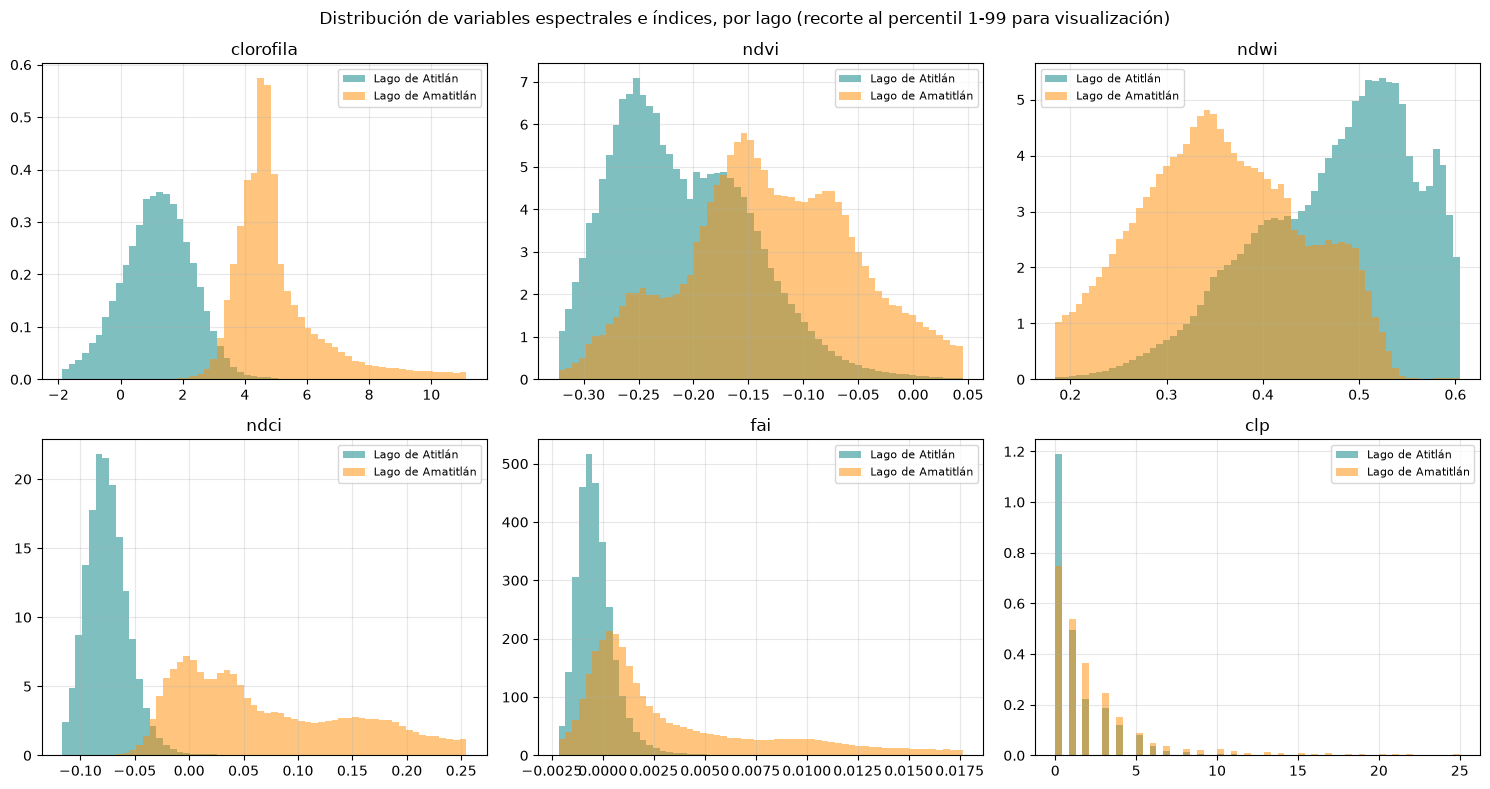

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
variables_hist = ["clorofila", "ndvi", "ndwi", "ndci", "fai", "clp"]
for ax, var in zip(axes.ravel(), variables_hist):
    p1, p99 = np.nanpercentile(dataset[var], [1, 99])
    for lago in LAGOS:
        sub = dataset.loc[dataset["lago"] == lago, var]
        ax.hist(sub, bins=60, range=(p1, p99), alpha=0.5, density=True, label=LAGOS[lago]["nombre"], color=colores[lago])
    ax.set_title(var)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle("Distribución de variables espectrales e índices, por lago (recorte al percentil 1-99 para visualización)")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "p2_distribuciones_variables.png", dpi=150)
plt.show()

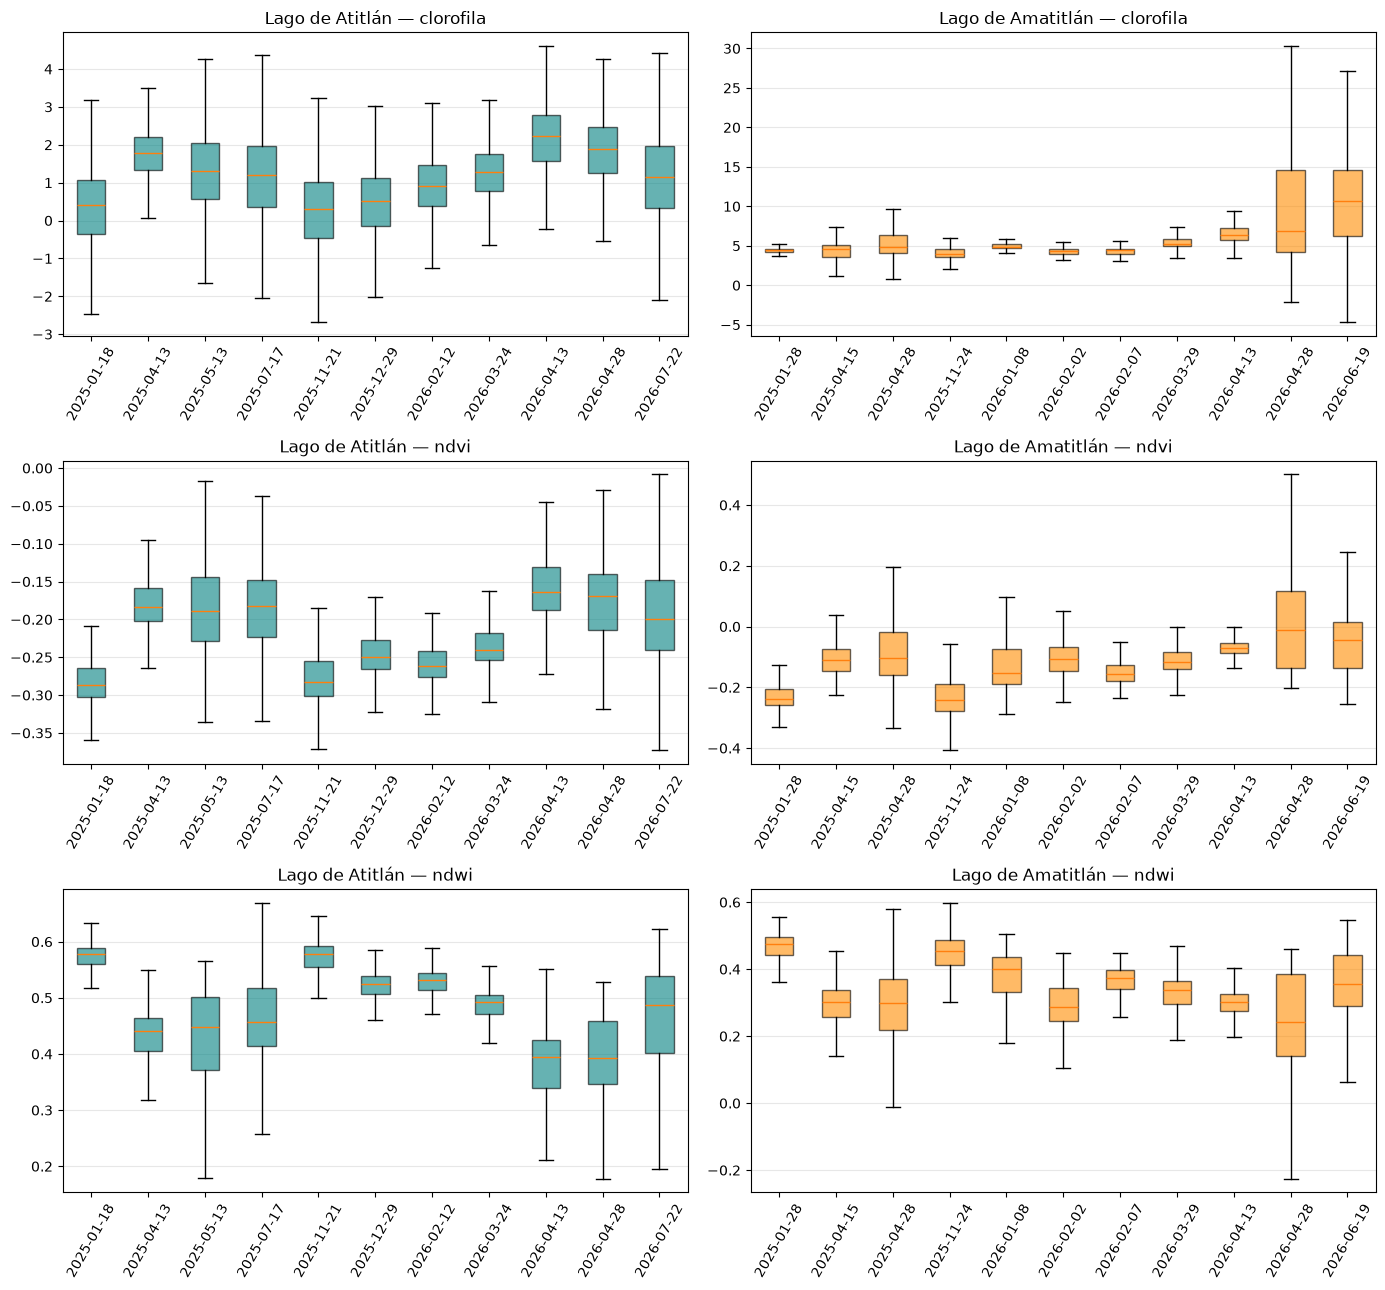

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
for col, lago in enumerate(LAGOS):
    sub = dataset[dataset["lago"] == lago]
    fechas_lago = sorted(sub["fecha"].unique())
    for row, var in enumerate(["clorofila", "ndvi", "ndwi"]):
        ax = axes[row, col]
        datos_por_fecha = [sub.loc[sub["fecha"] == f, var] for f in fechas_lago]
        ax.boxplot(
            datos_por_fecha,
            tick_labels=[pd.Timestamp(f).strftime("%Y-%m-%d") for f in fechas_lago],
            patch_artist=True,
            boxprops=dict(facecolor=colores[lago], alpha=0.6),
            showfliers=False,
        )
        ax.set_title(f"{LAGOS[lago]['nombre']} — {var}")
        ax.tick_params(axis="x", rotation=60)
        ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "p2_boxplots_por_fecha.png", dpi=150)
plt.show()

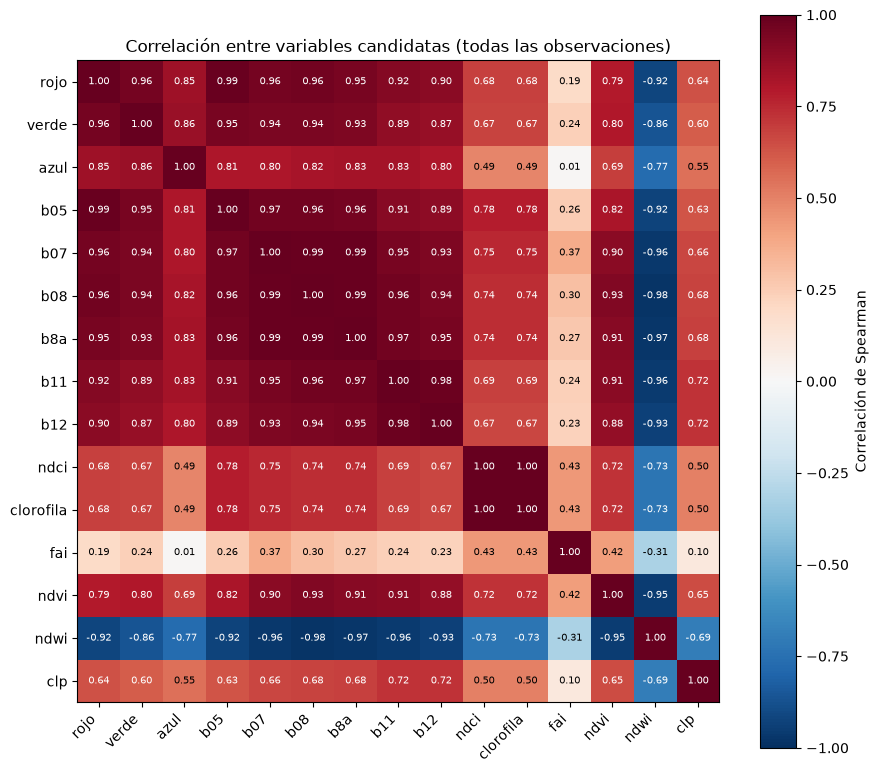

In [12]:
corr = dataset[variables_modelado].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(variables_modelado)))
ax.set_xticklabels(variables_modelado, rotation=45, ha="right")
ax.set_yticks(range(len(variables_modelado)))
ax.set_yticklabels(variables_modelado)
for i in range(len(variables_modelado)):
    for j in range(len(variables_modelado)):
        ax.text(
            j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7,
            color="white" if abs(corr.iloc[i, j]) > 0.6 else "black",
        )
fig.colorbar(im, ax=ax, label="Correlación de Spearman")
ax.set_title("Correlación entre variables candidatas (todas las observaciones)")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "p2_correlacion_variables.png", dpi=150)
plt.show()

`ndci` y `clorofila` están casi perfectamente correlacionadas entre sí, y ambas con `rojo` y `b05`, porque `clorofila` es una transformación polinomial directa de `ndci`, que a su vez se calcula a partir de `rojo` (B04) y `b05` (B05). Esto confirma, desde el inciso 1, que ninguna de las cuatro puede usarse simultáneamente como predictora junto con la variable respuesta que se construirá en el inciso 2 a partir de `clorofila`: `rojo`, `b05` y `ndci` quedan excluidas como predictoras porque participan directamente en su construcción. `ndvi` y `ndwi` muestran una correlación negativa moderada a fuerte con `clorofila`, consistente con lo reportado en la Parte I, pero no intervienen en su cálculo, por lo que sí pueden usarse como predictoras.

### Cobertura espacial: dónde se concentra cada motivo de descarte

Para una fecha representativa de cada lago se clasifica cada píxel del raster completo según el primer filtro del inciso 1.1-1.3 que lo descarta (`src.dataset.mapa_motivo_descarte`), lo que permite ver si los descartes se concentran en zonas específicas del lago o están distribuidos de forma dispersa.

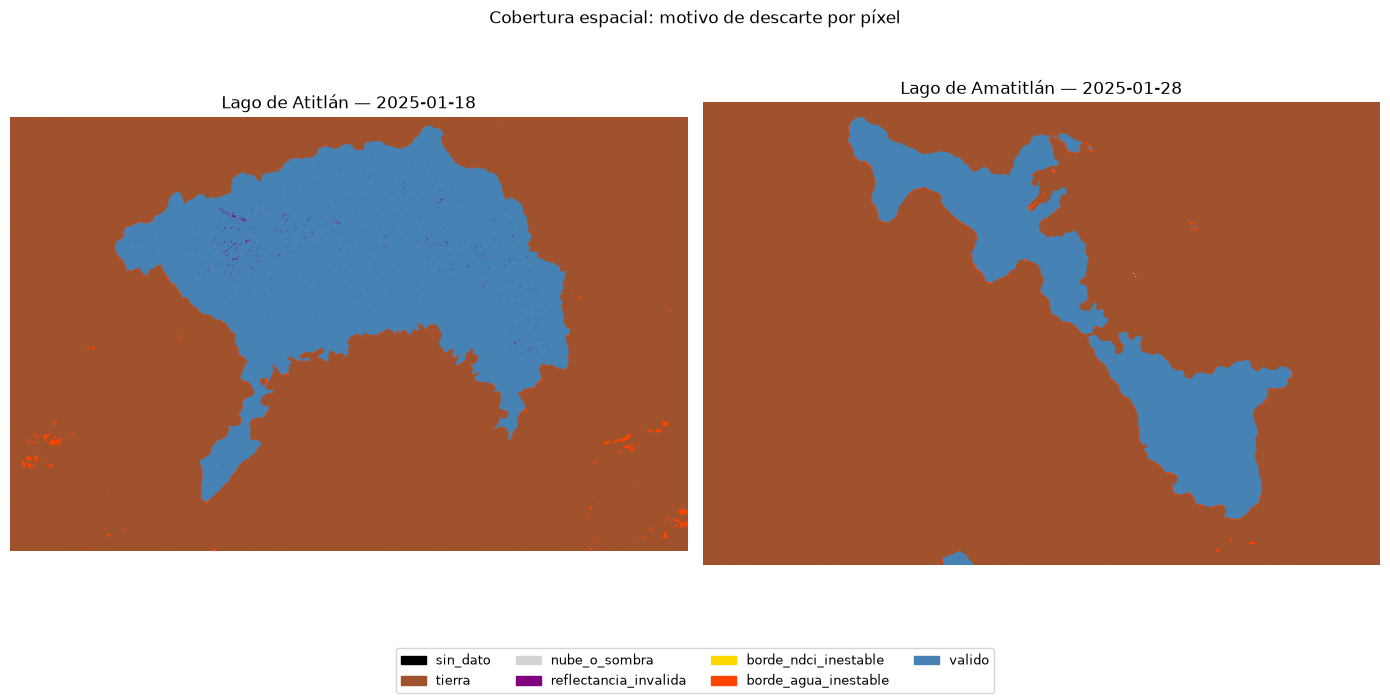

In [13]:
fecha_ejemplo = {lago: FECHAS_OFICIALES[lago][0] for lago in LAGOS}
etiquetas_color = {
    "sin_dato": "black",
    "tierra": "sienna",
    "nube_o_sombra": "lightgray",
    "reflectancia_invalida": "purple",
    "borde_ndci_inestable": "gold",
    "borde_agua_inestable": "orangered",
    "valido": "steelblue",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, lago in zip(axes, LAGOS):
    fecha = fecha_ejemplo[lago]
    estable = mascara_agua_estable(lago)
    motivo, etiquetas = mapa_motivo_descarte(lago, fecha, mascara_estable=estable)
    cmap = mcolors.ListedColormap([etiquetas_color[e] for e in etiquetas])
    ax.imshow(motivo, cmap=cmap, vmin=0, vmax=len(etiquetas) - 1)
    ax.set_title(f"{LAGOS[lago]['nombre']} — {fecha}")
    ax.axis("off")

parches = [mpatches.Patch(color=color, label=etiqueta) for etiqueta, color in etiquetas_color.items()]
fig.legend(handles=parches, loc="lower center", ncol=4, fontsize=9)
fig.suptitle("Cobertura espacial: motivo de descarte por píxel")
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(RUTA_FIGURAS / "p2_cobertura_espacial.png", dpi=150)
plt.show()

En ambas fechas, la categoría `tierra` domina fuera del contorno del lago, como se espera, y las observaciones `válido` cubren la práctica totalidad del cuerpo de agua. Las categorías de descarte por calidad (`nube_o_sombra`, `reflectancia_invalida`, `borde_ndci_inestable`, `borde_agua_inestable`) aparecen como un borde delgado alrededor del contorno del agua, no como regiones internas extensas, lo que respalda que la limpieza no introduce huecos relevantes dentro del área de estudio.

### Self-check

In [14]:
assert dataset[variables_modelado].isna().sum().sum() == 0, "hay valores faltantes en columnas de modelado"

for lago in LAGOS:
    n_fechas_dataset = dataset.loc[dataset["lago"] == lago, "fecha"].nunique()
    assert n_fechas_dataset == len(FECHAS_OFICIALES[lago]), f"{lago}: número de fechas no coincide con FECHAS_OFICIALES"

transformador = Transformer.from_crs("EPSG:4326", "EPSG:32615", always_xy=True)
for lago in LAGOS:
    oeste, sur, este, norte = LAGOS[lago]["bbox"]
    x_a, y_a = transformador.transform(oeste, sur)
    x_b, y_b = transformador.transform(este, norte)
    x_min, x_max = min(x_a, x_b), max(x_a, x_b)
    y_min, y_max = min(y_a, y_b), max(y_a, y_b)
    sub = dataset[dataset["lago"] == lago]
    assert sub["x_utm"].between(x_min - 100, x_max + 100).all(), f"{lago}: x_utm fuera del bbox reproyectado"
    assert sub["y_utm"].between(y_min - 100, y_max + 100).all(), f"{lago}: y_utm fuera del bbox reproyectado"

print("OK: dataset_ml.parquet es consistente.")

OK: dataset_ml.parquet es consistente.


### Guardado del dataset completo y de la muestra de trabajo

In [15]:
dataset.to_parquet(RUTA_DATA_PROCESSED / "dataset_ml.parquet", index=False)

muestra = muestra_trabajo(dataset)
muestra.to_parquet(RUTA_DATA_PROCESSED / "dataset_ml_muestra.parquet", index=False)

print(f"dataset_ml.parquet: {len(dataset):,} filas")
print(f"dataset_ml_muestra.parquet: {len(muestra):,} filas")
print(muestra.groupby(['lago', 'fecha'], observed=True).size().groupby('lago').agg(['min', 'max']))

dataset_ml.parquet: 3,753,732 filas
dataset_ml_muestra.parquet: 299,992 filas
             min    max
lago                   
amatitlan  13636  13636
atitlan    13636  13636


## 1.6 Decisiones tomadas durante la preparación y limpieza

- **Ampliación del evalscript.** La Parte I solo devolvía 3 bandas ópticas crudas (B02, B03, B04); con solo esas, casi no quedaban bandas espectrales disponibles como predictoras. Como los 22 rasters debían re-descargarse de todas formas para este inciso, se amplió `EVALSCRIPT_CIANOBACTERIA` para devolver también B05, B07, B08, B8A, B11, B12, y las bandas de nube CLM y CLP de Sentinel Hub, anexadas después de las 10 bandas originales para no afectar los notebooks de la Parte I.
- **Filtro de nubes basado en CLP, no solo en CLM.** Al construir el dataset se detectó que `CLM == 255` ("sin dato" del modelo s2cloudless) no es sinónimo de nube: en tres de las 22 fechas, tratarlo como nube descartaba entre 43% y 92% de píxeles de agua con reflectancia y `CLP` normales. El filtro final excluye únicamente `CLM == 1` (nube confirmada) y usa `CLP < 0.35` como criterio continuo de nubosidad, evaluado directamente sobre cada píxel en lugar de depender del porcentaje de nubosidad reportado a nivel de escena completa en `NUBOSIDAD_OFICIAL` de la Parte I.
- **Reproyección a UTM 15N desde este inciso.** El enunciado exige EPSG:32615 para la validación espacial del inciso 6; se reproyecta aquí, junto con el resto de la limpieza, para no recalcular coordenadas más adelante y para poder validar el rango de las coordenadas de cada lago en el self-check de este mismo inciso.
- **Máscara de agua estable.** Se reutiliza el criterio del inciso 8 de la Parte I (píxel clasificado como agua en al menos 9 de las 11 fechas oficiales de su lago) para descartar píxeles de borde con ratios espectrales inestables, en lugar de solo la máscara de agua de la fecha individual.
- **Columnas descartadas de la tabla final.** `mascara`, `agua` y `clm` se usan como filtros pero no se conservan como columnas: tras aplicar los filtros quedan en un valor constante (1, 1 y 0 respectivamente) y no aportan información como predictoras.
- **Fecha con cobertura parcial reportada (Amatitlán, 2026-02-07).** La Parte I había señalado esta fecha con 57.1% de cobertura por nubes según el catálogo. Al revisar los conteos del inciso 1.3 (36,792 de 36,896 píxeles de agua retenidos, 99.7%), se confirma lo ya observado en la Parte I: para el área específica del lago, la imagen está prácticamente libre de nubes, y la fecha se mantiene sin ajustes adicionales.
- **Muestra de trabajo para modelado.** El dataset completo tiene más de 3.7 millones de filas, lo que haría lento el ajuste de hiperparámetros, la validación espacial (inciso 6) y SHAP (inciso 8) sin aportar precisión adicional relevante. Se guarda también `dataset_ml_muestra.parquet`, un submuestreo aleatorio reproducible (semilla fija) de 150,000 observaciones por lago, repartidas en partes iguales entre las 11 fechas de cada lago.